# 02 · the maths and statistics you will lean on

### CAJAL NEUROMICS summer school, Bordeaux 2026 · a spatial metabolomics primer

You have a terminal that works (notebook 00) and you can read and nudge Python (notebook 01).
This notebook is the third leg of the stool: the **mathematics and statistics** that every
method in the course quietly stands on.

The plan is a revision, not a first contact. Many of you have met linear algebra and basic
statistics before; the goal here is to make those ideas *fluent and visual* again, so that when
the course notebooks reach for a dot product, a least-squares fit, or a t-test, the idea is
already warm in your hands. We assume a mixed background: if a section is familiar, skim it and
run the cell; if it is rusty, slow down, change a number, and watch what moves.

Two principles run through the whole notebook:

- **every idea gets a picture and a tiny runnable example** on synthetic data we build ourselves,
  with a fixed random seed, so the numbers are the same every time you run it.
- **we stop at the foundations.** The advanced methods (PCA, NMF, clustering, batch correction,
  the differential test) are taught later, in the course notebooks where they are actually used.
  Here we build the floor they stand on, and we say so when a foundation is about to become a
  method, without teaching the method.

The notebook has two halves: **linear algebra** (vectors, matrices, projections, eigenvectors)
and **probability and statistics** (distributions, correlation, regression, hypothesis testing).
Take a couple of hours. Run every cell. Read every figure.

A few callouts appear, used sparingly:

- 🔬 **TASK**: something to try yourself.
- 💡 **HINT**: a nudge when stuck.
- ❓ **QUESTION**: pause and think, no code required.

And where it helps, a plain **check:** line tells you what a correct screen looks like.

🔬 **TASK.** Run the next cell to load the small toolbox we use throughout: numpy for arrays and
linear algebra, scipy for statistics and curve fitting, matplotlib for figures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank, eig
from scipy import stats, optimize

# one global seed so every number and figure below is reproducible
rng = np.random.default_rng(0)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

import scipy
print("ready. numpy", np.__version__, "| scipy", scipy.__version__)

ready. numpy 2.2.6 | scipy 1.15.2


**check:** you should see `ready. numpy ... | scipy ...` and no red error. If you see a
`ModuleNotFoundError`, your notebook is on the wrong kernel: pick `cajal-lipidomics` from the
kernel selector (top right) and run the cell again.

---
# part 1 · linear algebra

Linear algebra is the grammar of data. A measurement is a list of numbers, a dataset is a grid of
numbers, and almost every analysis is some controlled way of adding, scaling, and rotating those
numbers. Get comfortable with five objects, vectors, matrices, the dot product, projections, and
eigenvectors, and the rest of the course reads like sentences instead of spells.

The single best companion to this half is 3Blue1Brown's *Essence of Linear Algebra*, a short
visual series that builds exactly the geometric intuition we use here:
<https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab>. For worked practice,
Khan Academy's linear algebra track is free and thorough:
<https://www.khanacademy.org/math/linear-algebra>.

## 1. vectors, the atoms of data

Start with three words. A **scalar** is a single number, like `3.0`. A **vector** is an ordered
list of numbers, like `[2, 1]`. A **matrix** is a rectangle of numbers, rows and columns. Scalars
scale, vectors point, matrices transform. Everything else is built from these.

A vector has two faces, and you need both. The **algebra** face: it is just a list, `[2, 1]`. The
**geometry** face: that same list is an **arrow** in space, the arrow that goes 2 steps along the
first axis and 1 step up the second. For us, one pixel of tissue is a vector: its list of lipid
intensities. Measure 8 lipids and each pixel is a vector of 8 numbers, an arrow in 8 dimensional
space. You cannot draw 8 dimensions, but the algebra is identical to the 2D case you can draw, and
that is the whole trick: reason in 2D, compute in any dimension.

Two operations are all a vector space is built on. **Addition** puts two arrows tip to tail:
`[2, 1] + [1, 3] = [3, 4]`. **Scaling** stretches one arrow by a scalar: `2 * [2, 1] = [4, 2]`,
same direction, twice as long. Negative scalars flip the direction. Let us draw both.

a       = [2. 1.]
b       = [1. 3.]
a + b   = [3. 4.]
2 * a   = [4. 2.]   (same direction, twice as long)


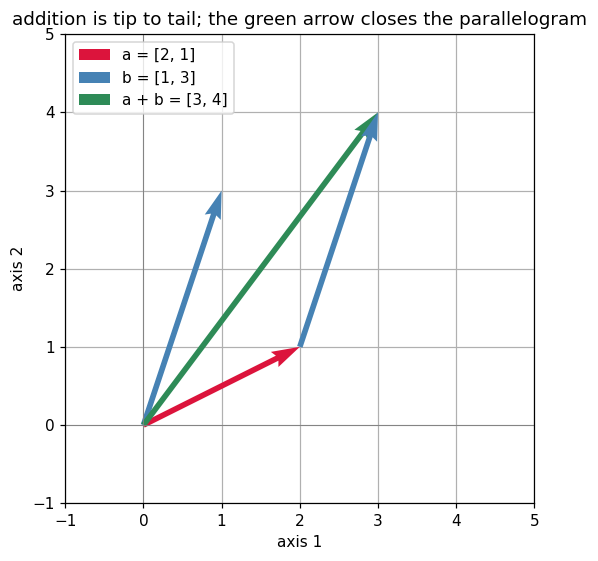

In [2]:
a = np.array([2.0, 1.0])
b = np.array([1.0, 3.0])
s = a + b                      # vector addition: tip to tail

print("a       =", a)
print("b       =", b)
print("a + b   =", s)
print("2 * a   =", 2 * a, "  (same direction, twice as long)")

def draw_arrow(ax, vec, color, label=None, start=(0.0, 0.0)):
    ax.quiver(start[0], start[1], vec[0], vec[1], angles="xy",
              scale_units="xy", scale=1, color=color, label=label, width=0.012)

fig, ax = plt.subplots(figsize=(5.2, 5.2))
draw_arrow(ax, a, "crimson", "a = [2, 1]")
draw_arrow(ax, b, "steelblue", "b = [1, 3]")
draw_arrow(ax, s, "seagreen", "a + b = [3, 4]")
draw_arrow(ax, b, "steelblue", None, start=a)   # b again, started at tip of a -> the parallelogram
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5); ax.set_aspect("equal")
ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
ax.set_xlabel("axis 1"); ax.set_ylabel("axis 2")
ax.set_title("addition is tip to tail; the green arrow closes the parallelogram")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

**check:** the green arrow `a + b` reaches the far corner of the parallelogram whose sides
are `a` and `b`. That is what vector addition *is*, geometrically.

❓ **QUESTION.** A pixel with lipid profile `[8, 2]` and another with `[4, 1]` point in the *same*
direction, one is just twice the other. Biologically they have the same lipid *composition* at
different total intensity. Hold that thought: telling "same direction" from "same length" apart is
exactly what the next section measures.

## 2. the dot product, length, and angle

The **dot product** of two vectors multiplies them entry by entry and sums the result. For
`a = [2, 1]` and `b = [1, 3]` it is `2*1 + 1*3 = 5`. One number falls out of two vectors, and that
number is loaded with geometry.

First, length. The **length** (or **norm**) of a vector is the dot product of the vector with
itself, square-rooted: `|a| = sqrt(a . a)`. For `[2, 1]` that is `sqrt(4 + 1) = sqrt(5)`. This is
just Pythagoras: the length of the arrow.

Second, angle. The dot product also obeys `a . b = |a| |b| cos(theta)`, where `theta` is the angle
between the two arrows. Rearrange and you can *read the angle straight out of the numbers*:
`cos(theta) = (a . b) / (|a| |b|)`. This cosine is the workhorse of "how similar are these two
profiles", because it ignores length and asks only about direction. Two arrows pointing the same
way give cosine 1 (angle 0). Perpendicular arrows give cosine 0 (angle 90 degrees), and their dot
product is exactly zero. Opposite arrows give cosine -1.

In [3]:
a = np.array([2.0, 1.0])
b = np.array([1.0, 3.0])

dot   = a @ b                       # @ is numpy's dot / matrix-multiply operator
len_a = norm(a)                     # sqrt(a . a)
len_b = norm(b)
cos_t = dot / (len_a * len_b)       # cosine of the angle between them
theta = np.degrees(np.arccos(cos_t))

print(f"a . b              = {dot:.3f}")
print(f"|a|, |b|           = {len_a:.3f}, {len_b:.3f}")
print(f"cos(theta)         = {cos_t:.3f}")
print(f"angle between them = {theta:.1f} degrees")

# a perpendicular pair: dot product is exactly zero
u = np.array([1.0, 0.0]); v = np.array([0.0, 1.0])
print(f"\nperpendicular check: [1,0] . [0,1] = {u @ v:.0f}  (zero means at right angles)")

a . b              = 5.000
|a|, |b|           = 2.236, 3.162
cos(theta)         = 0.707
angle between them = 45.0 degrees

perpendicular check: [1,0] . [0,1] = 0  (zero means at right angles)


**check:** the angle between `a` and `b` comes out near 45 degrees, and the perpendicular
pair dots to exactly 0. "Zero dot product" and "at right angles" are the same statement.

💡 **HINT.** The cosine of the angle, `cos(theta)`, is called **cosine similarity** and you will
meet it again as a way to compare lipid profiles regardless of overall intensity. It is nothing
more than the dot product, normalised by the two lengths.

## 3. a matrix two ways: a table, and a transformation

A matrix is a rectangle of numbers, and it wears two hats. You must be able to switch between them.

**Hat one: a matrix is a table of data.** Stack many pixel-vectors as rows and you get a matrix
where each **row is one sample** (a pixel) and each **column is one feature** (a lipid). The entry
at row *i*, column *j* is the intensity of lipid *j* in pixel *i*. A dataset of 300 pixels measured
at 8 lipids is a 300-by-8 matrix. This rows-are-samples, columns-are-features convention is the
bedrock shape of every tool in the course.

**Hat two: a matrix is a transformation of space.** A square matrix can also *act on* vectors:
multiply a vector by the matrix and you get a new vector, a moved version of the old one. The
matrix encodes a stretch, a rotation, a shear, or some combination. The cleanest way to see this is
to apply the matrix to a whole unit square and watch what the square becomes.

**Matrix multiplication** ties the two hats together. The product `A @ v` is built from dot
products: each entry of the output is one row of `A` dotted with `v`. Multiplying a matrix by a
matrix is just doing this for many vectors at once. That single operation, many dot products
bundled together, is how an entire dataset gets transformed in one step.

In [4]:
# hat one: a tiny data table, rows = pixels, columns = lipids
X = np.array([
    [8.0, 2.0, 3.0],   # pixel 0
    [7.5, 2.4, 2.8],   # pixel 1
    [3.0, 6.5, 5.0],   # pixel 2
    [3.4, 7.0, 4.6],   # pixel 3
])
print("data table, shape (pixels, lipids) =", X.shape)
print(X)
print("\nmean of each lipid (collapse the rows):", X.mean(axis=0).round(2))

data table, shape (pixels, lipids) = (4, 3)
[[8.  2.  3. ]
 [7.5 2.4 2.8]
 [3.  6.5 5. ]
 [3.4 7.  4.6]]

mean of each lipid (collapse the rows): [5.48 4.47 3.85]


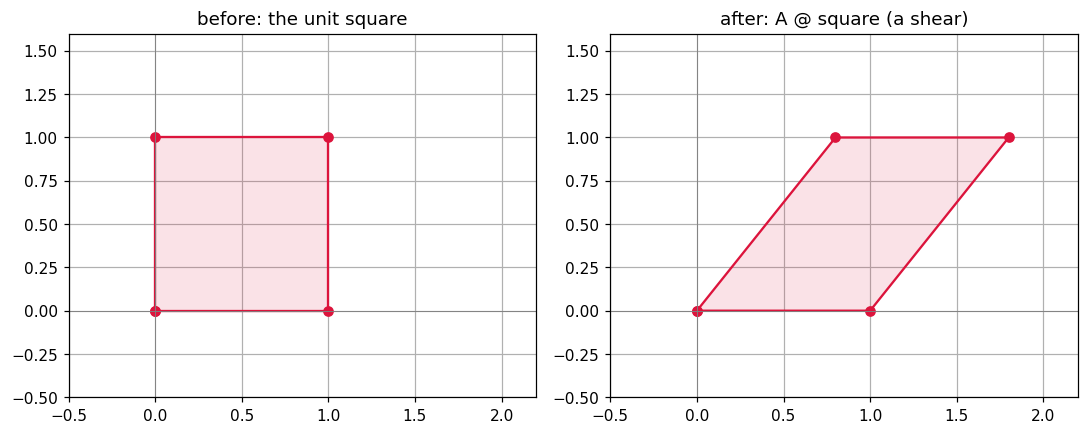

one column of A tells you where the matrix sends a basis arrow:
  A sends [1,0] -> [1. 0.]
  A sends [0,1] -> [0.8 1. ]


In [5]:
# hat two: the SAME kind of object as a transformation of space.
# A shears space horizontally; it leaves the vertical axis alone and tilts the rest.
A = np.array([[1.0, 0.8],
              [0.0, 1.0]])

# the four corners of the unit square (and back to the start so the outline closes)
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T   # shape (2, 5)
transformed = A @ square                                         # apply the matrix to every corner

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, pts, title in [(axes[0], square, "before: the unit square"),
                       (axes[1], transformed, "after: A @ square (a shear)")]:
    ax.plot(pts[0], pts[1], "-o", color="crimson")
    ax.fill(pts[0], pts[1], color="crimson", alpha=0.12)
    ax.set_xlim(-0.5, 2.2); ax.set_ylim(-0.5, 1.6); ax.set_aspect("equal")
    ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
    ax.set_title(title)
plt.tight_layout(); plt.show()

print("one column of A tells you where the matrix sends a basis arrow:")
print("  A sends [1,0] ->", (A @ np.array([1.0, 0.0])))
print("  A sends [0,1] ->", (A @ np.array([0.0, 1.0])))

**check:** the right panel is the square pushed sideways into a parallelogram. The bottom
edge stays put and the top edge slides right, because `A` sends `[1,0]` to itself and `[0,1]` to
`[0.8, 1]`. The columns of a matrix are simply *where it sends the basis arrows*, which is the
whole content of "a matrix is a transformation".

❓ **QUESTION.** The same `A @ v` operation reads a data table in one context and bends space in
another. Why is that not a contradiction? (Because both are the same arithmetic: rows of the matrix
dotted with the vector. The meaning lives in what the rows and columns *stand for*, not in the
multiplication.)

## 4. independence, basis, dimension, rank

How much *room* does a set of vectors actually fill? That question has four names.

A set of vectors is **linearly independent** when none of them can be built by scaling and adding
the others. If one vector is a combination of the rest, it is **dependent**: it adds no new
direction. `[1, 0, 0]`, `[0, 1, 0]`, and `[1, 1, 0]` are dependent, because the third is just the
first plus the second; together they still only sweep out a flat plane, not all of 3D space.

A **basis** is a minimal independent set that can build everything in the space by scaling and
adding. The number of vectors in a basis is the **dimension** of the space: 2 for a plane, 3 for
ordinary space, 8 for an 8-lipid feature space.

The **rank** of a matrix is the number of genuinely independent directions among its rows (equally,
its columns). It tells you the true dimensionality hiding inside the data. A 300-by-8 table of
lipid intensities has at most rank 8, but if several lipids always rise and fall together, the rank
is effectively lower: the data lives in fewer dimensions than the table is wide. That gap between
"columns you measured" and "directions that actually vary" is precisely the slack that
dimensionality-reduction methods exploit later. We name it now and stop there.

In [6]:
# a dependent set: the third row is the sum of the first two -> only 2 real directions
M_dep = np.array([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [1.0, 1.0, 0.0]])
print("dependent set, rank =", matrix_rank(M_dep), "(three rows, but only a 2D plane)")

# an independent set spanning all of 3D -> rank 3
M_ind = np.array([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
print("independent set, rank =", matrix_rank(M_ind), "(a basis for 3D space)")

# correlated 'lipids': two columns are near-copies, so the effective rank is low
base = rng.normal(size=(200, 1))
data = np.hstack([base, base * 1.5 + 0.01 * rng.normal(size=(200, 1)),
                  rng.normal(size=(200, 1))])
print("\n200x3 table with two near-identical columns, rank =", matrix_rank(data),
      "\n(numerically full, but the first two columns carry almost the same direction)")

dependent set, rank = 2 (three rows, but only a 2D plane)
independent set, rank = 3 (a basis for 3D space)

200x3 table with two near-identical columns, rank = 3 
(numerically full, but the first two columns carry almost the same direction)


💡 **HINT.** Rank is the honest answer to "how many independent things am I really
measuring?". When columns of a data matrix are strongly correlated, the matrix is *close* to
lower rank, and that closeness is the opening that compression methods use to summarise many
lipids with a few numbers. The course returns to this; here you only need the word.

## 5. projecting one vector onto another

Often you want the **shadow** of one vector along the direction of another: how much of `a` points
along `b`. That shadow is the **projection** of `a` onto `b`, and it is built entirely from dot
products:

> `projection of a onto b = ( (a . b) / (b . b) ) * b`

Read it in two pieces. The scalar `(a . b) / (b . b)` is *how many copies of `b`* you need; the
trailing `* b` turns that number back into an arrow along `b`. The leftover, `a` minus its
projection, is the part of `a` perpendicular to `b`, the **residual**. Projection splits any vector
cleanly into "along this direction" plus "everything else".

This one operation is doing quiet work everywhere downstream. Fitting a line by least squares (part
2) is a projection. Reducing dimensions is choosing a few good directions and projecting the data
onto them. So the picture below is worth holding precisely.

projection of a onto b = [3. 0.]   (scale = 0.750)
residual (a - proj)    = [0. 2.]
residual . b           = 0.000  (zero: the leftover is perpendicular to b)


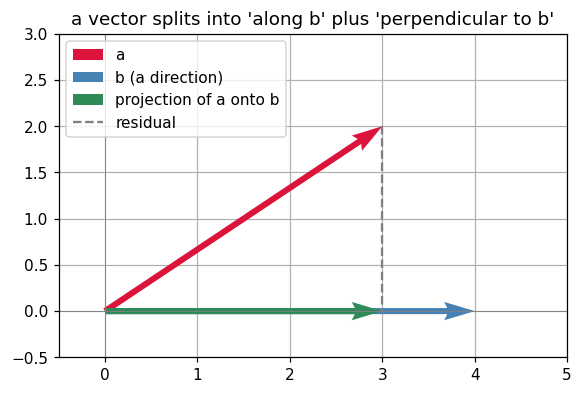

In [7]:
a = np.array([3.0, 2.0])
b = np.array([4.0, 0.0])    # b lies along the horizontal axis, so the shadow is easy to read

scale = (a @ b) / (b @ b)   # how many copies of b
proj  = scale * b           # the projection (shadow) of a onto b
resid = a - proj            # the leftover, perpendicular to b

print(f"projection of a onto b = {proj}   (scale = {scale:.3f})")
print(f"residual (a - proj)    = {resid}")
print(f"residual . b           = {resid @ b:.3f}  (zero: the leftover is perpendicular to b)")

fig, ax = plt.subplots(figsize=(5.4, 5.0))
draw_arrow(ax, a, "crimson", "a")
draw_arrow(ax, b, "steelblue", "b (a direction)")
draw_arrow(ax, proj, "seagreen", "projection of a onto b")
ax.plot([a[0], proj[0]], [a[1], proj[1]], "--", color="grey", label="residual")
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 3); ax.set_aspect("equal")
ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
ax.set_title("a vector splits into 'along b' plus 'perpendicular to b'")
ax.legend(); plt.tight_layout(); plt.show()

**check:** the dashed residual meets `b` at a right angle, and `residual . b` prints as 0.
The projection is the foot of the perpendicular dropped from the tip of `a` onto the line through
`b`. That right angle is not a coincidence: the projection is, by construction, the closest point
on `b`'s line to `a`, and "closest" always means "perpendicular leftover".

## 6. eigenvectors and eigenvalues

Most vectors, when you hit them with a matrix, both turn and stretch. A few special vectors do not
turn at all: the matrix only stretches (or shrinks, or flips) them, leaving their direction alone.
Those are the **eigenvectors** of the matrix, and the factor by which each is stretched is its
**eigenvalue**. In symbols, an eigenvector `v` and its eigenvalue `lambda` satisfy

> `A v = lambda v`

the matrix `A` acting on `v` is the same as just scaling `v` by the number `lambda`. The
eigenvectors are the matrix's own private axes, the directions along which its action is pure
stretch. The eigenvalues say how much stretch along each.

Let us find them for a symmetric 2-by-2 matrix and check the defining equation by hand.

In [8]:
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])

vals, vecs = eig(A)          # eigenvalues in vals, eigenvectors as the COLUMNS of vecs
print("eigenvalues :", np.round(vals, 3))
for i in range(2):
    lam = vals[i]; v = vecs[:, i]
    print(f"\neigenvector {i+1}: {np.round(v, 3)}  (eigenvalue {lam:.1f})")
    print(f"   A @ v     = {np.round(A @ v, 3)}")
    print(f"   lambda*v  = {np.round(lam * v, 3)}   <- identical, so A only stretched v")

eigenvalues : [3. 1.]

eigenvector 1: [0.707 0.707]  (eigenvalue 3.0)
   A @ v     = [2.121 2.121]
   lambda*v  = [2.121 2.121]   <- identical, so A only stretched v

eigenvector 2: [-0.707  0.707]  (eigenvalue 1.0)
   A @ v     = [-0.707  0.707]
   lambda*v  = [-0.707  0.707]   <- identical, so A only stretched v


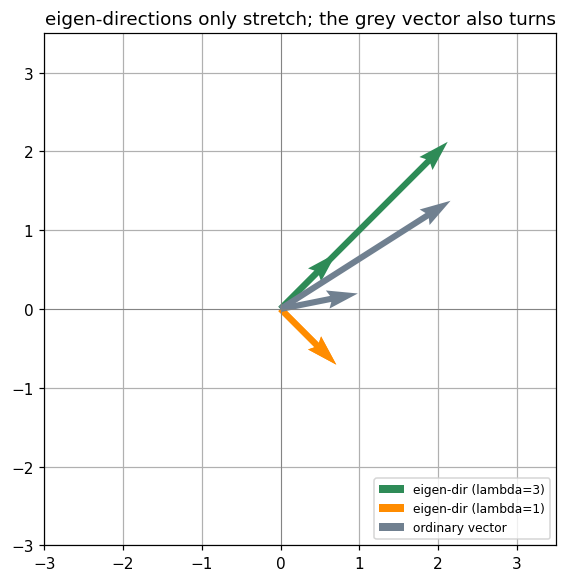

In [9]:
# picture: A stretches its eigen-directions but spins every other arrow off its line
fig, ax = plt.subplots(figsize=(5.4, 5.4))
for vec, color, lab in [(np.array([1.0, 1.0]),  "seagreen", "eigen-dir (lambda=3)"),
                        (np.array([1.0, -1.0]), "darkorange", "eigen-dir (lambda=1)"),
                        (np.array([1.0, 0.2]),  "slategrey", "ordinary vector")]:
    v = vec / norm(vec)
    Av = A @ v
    draw_arrow(ax, v, color, lab)
    draw_arrow(ax, Av, color)                 # same colour, longer: A applied
ax.set_xlim(-3, 3.5); ax.set_ylim(-3, 3.5); ax.set_aspect("equal")
ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
ax.set_title("eigen-directions only stretch; the grey vector also turns")
ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

**check:** along the two eigen-directions, `A @ v` lands exactly on the same line as `v`,
just longer (by 3 and by 1). The grey ordinary vector, by contrast, gets rotated off its original
line. Only eigenvectors keep their heading.

This is the foundation a major method of the course will later stand on. When the matrix `A` is a
**covariance matrix** (a square table describing how features vary together), its eigenvectors
point along the directions the data spreads most, and the eigenvalues measure how much spread sits
along each. "The directions the data varies most" and "the top eigenvectors of the covariance" are
the same sentence said twice. That is the engine inside principal component analysis. We are
deliberately stopping at the engine: PCA itself, the scree plot, the choice of how many components
to keep, is taught in the course notebook where you use it.

A short visual refresher on eigenvectors lives in 3Blue1Brown's *Essence of Linear Algebra*,
chapter 14: the same playlist linked at the top of part 1.

---
# part 2 · probability and statistics

Measurements wobble. Run the same assay twice and the numbers differ a little; that wobble is not a
failure, it is the thing statistics is built to reason about. This half gives you the vocabulary to
say, precisely, when a difference is real signal and when it is just the wobble.

Two free resources are worth opening alongside this half. **Seeing Theory** (Brown University) is a
set of interactive visualisations for exactly these ideas, distributions, the central limit
theorem, regression, inference: <https://seeing-theory.brown.edu/>. **StatQuest** (Josh Starmer)
explains each concept in short, friendly videos; its index is at
<https://statquest.org/video_index.html>, and the *Statistics Fundamentals* playlist is at
<https://www.youtube.com/playlist?list=PLblh5JKOoLUK0FLuzwntyYI10UQFUhsY9>. For the scipy and numpy
how-to underneath the examples, the **Scientific Python Lectures** are the standard reference:
<https://lectures.scientific-python.org/>.

## 7. random variables and the normal distribution

A **random variable** is a number whose value is set by chance: the intensity of one lipid in one
randomly chosen pixel, say. We do not know the next value exactly, but we know the *distribution*,
the shape that tells us which values are common and which are rare.

The most important shape is the **normal** (or **Gaussian**) distribution, the bell curve. It is
fixed by two numbers: its **mean** (where the bell is centred) and its **standard deviation** (how
wide it is). Three summaries describe any distribution and you should keep them straight:

- the **mean** is the average value, the balance point.
- the **variance** is the average squared distance from the mean: how spread out the values are.
- the **standard deviation** is the square root of the variance, back in the original units, which
  makes it the readable measure of spread.

Why does the bell curve appear so relentlessly in real data? The **central limit theorem**: when
many small, independent effects add up, their sum tends toward a normal distribution almost
regardless of the shape of each individual effect. A measured intensity is the sum of countless
tiny contributions, so it often lands close to bell-shaped. Let us see both halves: a normal
sample matching its formula, and a sum of decidedly non-normal pieces drifting toward a bell.

set mean   = 5.00,  sample mean   = 5.01
set std    = 2.00,  sample std    = 2.00
sample variance = 4.00  (std squared = 4.00)


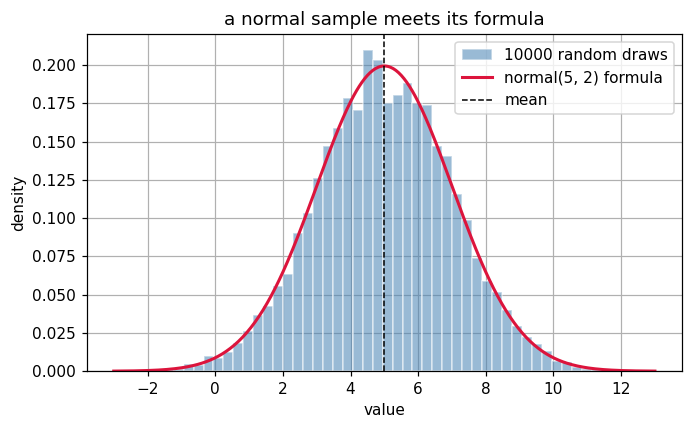

In [10]:
# draw a large normal sample and overlay the formula it was drawn from
mu, sigma = 5.0, 2.0
sample = rng.normal(loc=mu, scale=sigma, size=10000)

print(f"set mean   = {mu:.2f},  sample mean   = {sample.mean():.2f}")
print(f"set std    = {sigma:.2f},  sample std    = {sample.std():.2f}")
print(f"sample variance = {sample.var():.2f}  (std squared = {sigma**2:.2f})")

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, mu, sigma)        # the exact bell-curve formula

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.hist(sample, bins=50, density=True, color="steelblue", alpha=0.55, edgecolor="white",
        label="10000 random draws")
ax.plot(x, pdf, color="crimson", lw=2, label="normal(5, 2) formula")
ax.axvline(mu, color="black", ls="--", lw=1, label="mean")
ax.set_xlabel("value"); ax.set_ylabel("density"); ax.set_title("a normal sample meets its formula")
ax.legend(); plt.tight_layout(); plt.show()

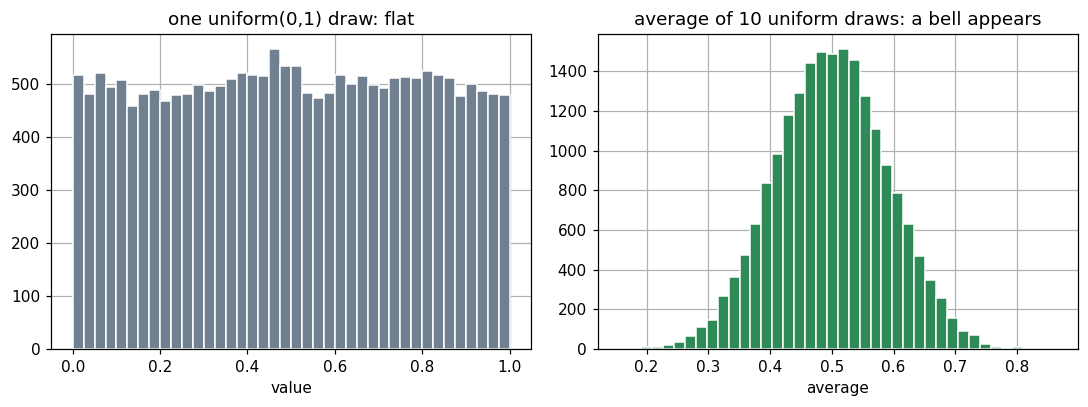

In [11]:
# central limit theorem in one picture: averages of a FLAT (uniform) variable go bell-shaped
single  = rng.uniform(0, 1, size=20000)                       # one flat draw: no bell at all
avg_of_10 = rng.uniform(0, 1, size=(20000, 10)).mean(axis=1)  # average of 10 flat draws each

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=False)
axes[0].hist(single, bins=40, color="slategrey", edgecolor="white")
axes[0].set_title("one uniform(0,1) draw: flat"); axes[0].set_xlabel("value")
axes[1].hist(avg_of_10, bins=40, color="seagreen", edgecolor="white")
axes[1].set_title("average of 10 uniform draws: a bell appears"); axes[1].set_xlabel("average")
plt.tight_layout(); plt.show()

**check:** the left histogram is flat (a uniform variable has no preferred value), yet the
right one, built only by *averaging ten* of those flat draws, is already bell-shaped and narrower.
That is the central limit theorem in miniature, and it is why the normal distribution and the
averaging in the next section are so central.

A gentle visual tour of distributions and the central limit theorem lives in Seeing Theory's
"Probability Distributions" chapter, linked above.

## 8. a sample, a population, and the standard error of the mean

A **population** is every value you *could* measure: the true distribution of a lipid across all
possible pixels. A **sample** is the finite handful you actually measured. You never see the
population directly; you estimate it from the sample, and the gap between the two is where careful
statistics earns its keep.

Here is the key move. The **sample mean** is itself a random variable: measure a different handful
and you get a slightly different mean. If you imagine repeating the whole experiment many times and
collecting all those means, their distribution is the **sampling distribution of the mean**. Its
spread has a name, the **standard error of the mean** (SEM), and a beautifully simple formula:

> `SEM = sigma / sqrt(n)`

the population standard deviation divided by the square root of the sample size. The message is
blunt and useful: bigger samples pin down the mean more tightly, but only as `sqrt(n)`, so halving
your uncertainty costs *four times* the data. Let us confirm the formula by brute force.

predicted SEM = sigma/sqrt(n) = 3.0/sqrt(25) = 0.600
observed spread of the 5000 sample means = 0.595
(the single-sample spread, sigma, was 3.0: the mean is far steadier than one value)


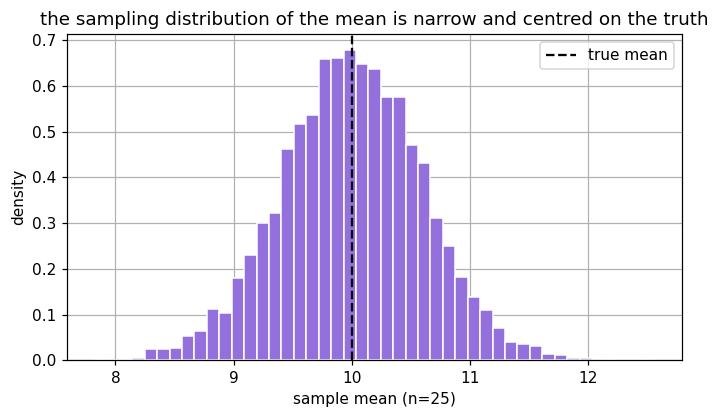

In [12]:
pop_mu, pop_sigma = 10.0, 3.0    # the (pretend) true population
n = 25                            # size of each sample we draw
n_experiments = 5000              # how many times we repeat the experiment

# repeat the experiment 5000 times, each time recording the sample mean
sample_means = rng.normal(pop_mu, pop_sigma, size=(n_experiments, n)).mean(axis=1)

predicted_sem = pop_sigma / np.sqrt(n)
observed_sem  = sample_means.std()
print(f"predicted SEM = sigma/sqrt(n) = {pop_sigma}/sqrt({n}) = {predicted_sem:.3f}")
print(f"observed spread of the 5000 sample means = {observed_sem:.3f}")
print(f"(the single-sample spread, sigma, was {pop_sigma}: the mean is far steadier than one value)")

fig, ax = plt.subplots(figsize=(6.4, 3.9))
ax.hist(sample_means, bins=45, density=True, color="mediumpurple", edgecolor="white")
ax.axvline(pop_mu, color="black", ls="--", label="true mean")
ax.set_xlabel("sample mean (n=25)"); ax.set_ylabel("density")
ax.set_title("the sampling distribution of the mean is narrow and centred on the truth")
ax.legend(); plt.tight_layout(); plt.show()

**check:** the observed spread of the 5000 sample means matches `sigma/sqrt(n)` closely,
and the histogram is far narrower than the population's own spread of 3. Averaging tames noise, and
the SEM is exactly how much.

This is the quantity that turns into **confidence intervals** and the denominator of the **t-test**
below, so it is worth internalising now: a mean estimated from `n` points carries an uncertainty of
about `sigma/sqrt(n)`.

## 9. Pearson correlation

Two measurements often move together. When one lipid is high, is another high too? **Pearson
correlation** puts a single number on that linear co-movement, between -1 and +1:

- **+1**: perfectly in step, one rises exactly as the other rises.
- **0**: no linear relationship.
- **-1**: perfectly opposed, one rises exactly as the other falls.

Mechanically it is the average product of the two variables *after each has been centred and scaled
to unit spread*, which is just the cosine similarity from part 1 applied to mean-centred data.
Geometry and statistics meeting again. Two warnings to carry: correlation sees only *linear*
structure (a perfect U-shape can have correlation near 0), and correlation is not causation.

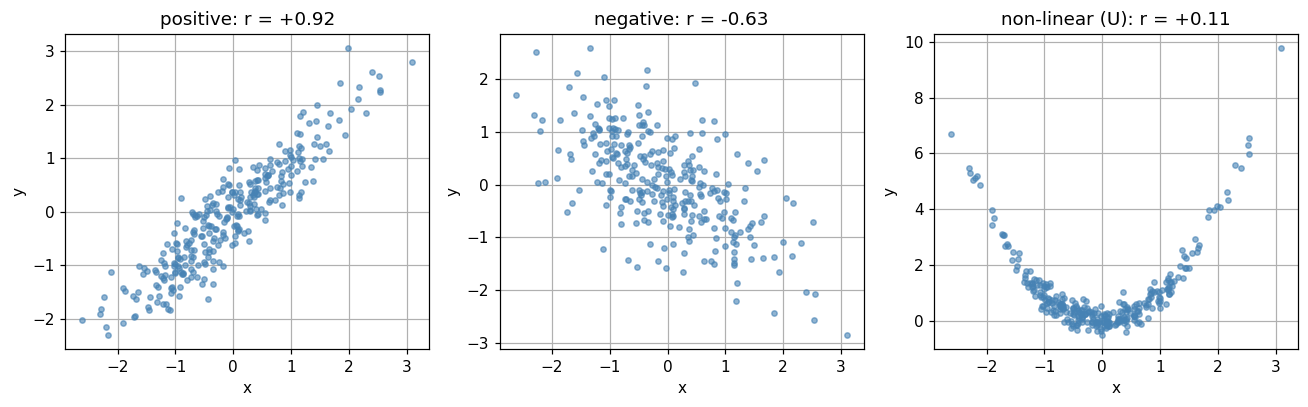

In [13]:
# build three relationships and measure each with scipy.stats.pearsonr
n = 300
x = rng.normal(0, 1, n)
y_pos = 0.9 * x + 0.4 * rng.normal(0, 1, n)    # strong positive
y_neg = -0.6 * x + 0.7 * rng.normal(0, 1, n)   # moderate negative
y_non = x**2 + 0.3 * rng.normal(0, 1, n)       # strong but NON-linear (a U)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, y, title in [(axes[0], y_pos, "positive"),
                     (axes[1], y_neg, "negative"),
                     (axes[2], y_non, "non-linear (U)")]:
    r, p = stats.pearsonr(x, y)
    ax.scatter(x, y, s=12, alpha=0.6, color="steelblue")
    ax.set_title(f"{title}: r = {r:+.2f}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

**check:** the positive cloud reports `r` near +0.9, the negative one a clear minus, and
the U-shape, despite being tightly structured, reports `r` near 0. Pearson correlation only sees
*straight-line* co-movement; a strong curved relationship can slip right past it. Always plot the
scatter, never trust the single number alone.

StatQuest's "Pearson's Correlation, Clearly Explained" (in the video index linked above) is a good
five-minute refresher.

## 10. linear regression by least squares

Correlation says *whether* two variables move together. **Linear regression** says *by how much*:
it fits the best straight line `y = slope * x + intercept` through a cloud of points, so you can
predict `y` from `x` and read off the rate of change.

"Best" needs a definition, and least squares gives the standard one. For any candidate line, each
point has a **residual**: the vertical gap between the real `y` and the line's prediction. Square
every residual (so positives and negatives cannot cancel, and big misses are punished hard) and add
them up. The **least-squares** line is the one that makes that total as small as possible. There is
a clean closed-form answer, but in practice you call a one-liner.

To judge the fit, **R squared** reports the fraction of the variance in `y` that the line explains,
from 0 (the line is useless, no better than predicting the mean) to 1 (the line passes through
every point). Let us fit a line end to end: generate data with a known slope, recover it, inspect
the residuals, and compute R squared.

In [14]:
# generate data from a KNOWN line, then pretend we do not know it and recover it
true_slope, true_intercept = 1.8, 4.0
x = np.linspace(0, 10, 60)
y = true_slope * x + true_intercept + rng.normal(0, 2.5, size=x.size)   # line plus noise

# fit by least squares. stats.linregress returns slope, intercept, r, p, and standard error
fit = stats.linregress(x, y)
y_hat = fit.slope * x + fit.intercept     # the line's predictions
residuals = y - y_hat                     # vertical gaps, the thing least squares minimises

print(f"true line:   y = {true_slope:.2f} x + {true_intercept:.2f}")
print(f"fitted line: y = {fit.slope:.2f} x + {fit.intercept:.2f}")
print(f"R squared = {fit.rvalue**2:.3f}  (fraction of variance in y explained by the line)")
print(f"slope p-value = {fit.pvalue:.2e}  (is the slope distinguishable from flat?)")

true line:   y = 1.80 x + 4.00
fitted line: y = 1.79 x + 3.97
R squared = 0.820  (fraction of variance in y explained by the line)
slope p-value = 3.10e-23  (is the slope distinguishable from flat?)


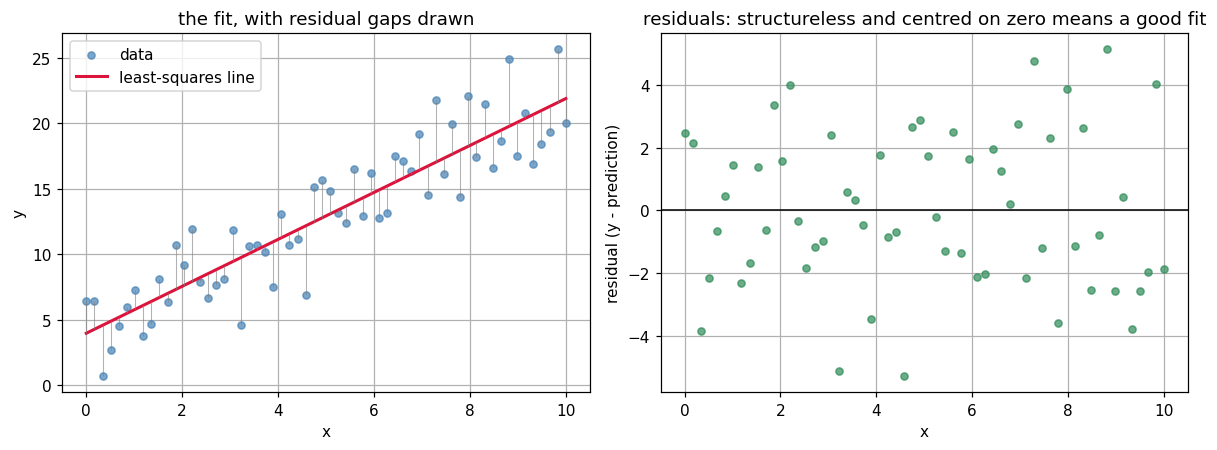

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# left: the data, the fitted line, and the residual gaps it minimised
axes[0].scatter(x, y, s=22, color="steelblue", alpha=0.7, label="data")
axes[0].plot(x, y_hat, color="crimson", lw=2, label="least-squares line")
axes[0].vlines(x, np.minimum(y, y_hat), np.maximum(y, y_hat),
               color="grey", lw=0.7, alpha=0.6)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("the fit, with residual gaps drawn"); axes[0].legend()

# right: residuals vs x. a good fit leaves a featureless, centred band
axes[1].scatter(x, residuals, s=22, color="seagreen", alpha=0.7)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xlabel("x"); axes[1].set_ylabel("residual (y - prediction)")
axes[1].set_title("residuals: structureless and centred on zero means a good fit")
plt.tight_layout(); plt.show()

**check:** the fitted slope and intercept land close to the true `1.8` and `4.0`, R squared
is high, and the residuals scatter in a flat band around zero with no leftover curve or fan shape.
A pattern in the residuals would be the data telling you a straight line is the wrong model, which
is the cue for the next section.

🔬 **TASK.** Change `rng.normal(0, 2.5, ...)` to `rng.normal(0, 6.0, ...)` and rerun both cells.
Watch R squared fall as the noise grows, even though the true slope is unchanged. R squared
measures how *tightly* the line fits, not whether the slope is real.

StatQuest's "Linear Regression, Clearly Explained" walks the same ideas:
<https://www.youtube.com/watch?v=7ArmBVF2dCs>.

## 11. fitting a curve: nonlinear regression

Not every relationship is a straight line. Many biological signals **saturate**: they climb fast at
first, then flatten toward a ceiling. A line cannot capture that, but the *idea* of fitting is
unchanged: pick a function with a few unknown **parameters**, then choose the parameters that make
the curve pass as close as possible to the data, again by least squares.

`scipy.optimize.curve_fit` does this for any function you can write down. We use a classic
saturating curve, `y = Vmax * x / (K + x)`, the Michaelis-Menten form, with two parameters: `Vmax`,
the ceiling the curve approaches, and `K`, the value of `x` at which `y` reaches half the ceiling.
You hand `curve_fit` the model and the data; it hands back the best-fit parameters.

true  : Vmax = 8.00, K = 2.00
fitted: Vmax = 8.05, K = 2.16


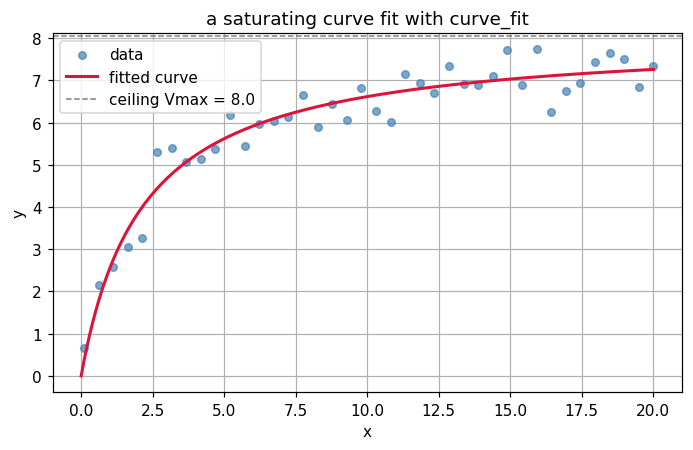

In [16]:
# the saturating model, written as a plain Python function of x and the parameters
def saturating(x, vmax, k):
    return vmax * x / (k + x)

# generate data from known parameters, then recover them
true_vmax, true_k = 8.0, 2.0
x = np.linspace(0.1, 20, 40)
y = saturating(x, true_vmax, true_k) + rng.normal(0, 0.4, size=x.size)

# curve_fit finds the parameters minimising the squared residuals; p0 is a starting guess
params, _ = optimize.curve_fit(saturating, x, y, p0=[1.0, 1.0])
fit_vmax, fit_k = params
print(f"true  : Vmax = {true_vmax:.2f}, K = {true_k:.2f}")
print(f"fitted: Vmax = {fit_vmax:.2f}, K = {fit_k:.2f}")

xx = np.linspace(0, 20, 200)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.scatter(x, y, s=24, color="steelblue", alpha=0.7, label="data")
ax.plot(xx, saturating(xx, *params), color="crimson", lw=2, label="fitted curve")
ax.axhline(fit_vmax, color="grey", ls="--", lw=1, label=f"ceiling Vmax = {fit_vmax:.1f}")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("a saturating curve fit with curve_fit")
ax.legend(); plt.tight_layout(); plt.show()

**check:** the recovered `Vmax` and `K` are close to the true `8.0` and `2.0`, and the red
curve hugs the data and flattens toward the dashed ceiling. The lesson generalises: *fitting a
model* means writing down a function with free parameters and letting the optimiser tune them to
the data. Linear regression is the special case where the function is a straight line.

## 12. hypothesis testing and the Student's t-test

Now the question the course is really built around: two groups of measurements differ in their
average, but is the difference *real*, or just the sampling wobble from part 8? Hypothesis testing
is the disciplined way to answer.

The logic has four moving parts:

- the **null hypothesis** is the boring default: "there is no real difference; the two groups come
  from the same population." We try to *disprove* this.
- a **test statistic** is a single number that measures how far the data departs from the null. For
  comparing two means it is the **t statistic**: the difference in means divided by an estimate of
  how much that difference could wobble by chance (a standard error). Big difference and small
  wobble give a big `t`.
- the **p-value** is the probability of seeing a `t` at least this extreme *if the null were true*.
  Small p means "this data would be surprising under no-difference", which is evidence *against* the
  null.
- the **significance level** (often 0.05) is the threshold you fix in advance. If `p` falls below
  it, you call the result statistically significant and reject the null. It is the false-alarm rate
  you are willing to tolerate.

The **Student's t-test** is the standard test for means. The **one-sample** version asks "is this
group's mean different from some fixed value?". The **two-sample** version asks "do these two
groups have different means?". The **degrees of freedom** (roughly, the sample sizes minus the
number of means estimated) set the exact shape of the t distribution the p-value is read from:
smaller samples give heavier tails, demanding a larger `t` for the same significance, which is the
test honestly accounting for how little data you have. Let us run both.

In [17]:
# one-sample t-test: is this group's mean different from a reference value of 5.0?
group = rng.normal(loc=5.8, scale=2.0, size=30)
t1 = stats.ttest_1samp(group, popmean=5.0)
print("one-sample t-test (mean vs 5.0)")
print(f"  sample mean = {group.mean():.2f}")
print(f"  t statistic = {t1.statistic:.2f},  df = {t1.df:.0f},  p-value = {t1.pvalue:.4f}")
print()

# two-sample t-test: do control and treated differ in mean? (a real difference is baked in)
control = rng.normal(loc=5.0, scale=2.0, size=40)
treated = rng.normal(loc=6.5, scale=2.0, size=40)
t2 = stats.ttest_ind(control, treated)
print("two-sample t-test (control vs treated)")
print(f"  control mean = {control.mean():.2f},  treated mean = {treated.mean():.2f}")
print(f"  t statistic = {t2.statistic:.2f},  df = {t2.df:.0f},  p-value = {t2.pvalue:.2e}")
print(f"  significant at 0.05? {t2.pvalue < 0.05}")

one-sample t-test (mean vs 5.0)
  sample mean = 6.07
  t statistic = 2.49,  df = 29,  p-value = 0.0189

two-sample t-test (control vs treated)
  control mean = 5.63,  treated mean = 5.81
  t statistic = -0.39,  df = 78,  p-value = 6.98e-01
  significant at 0.05? False


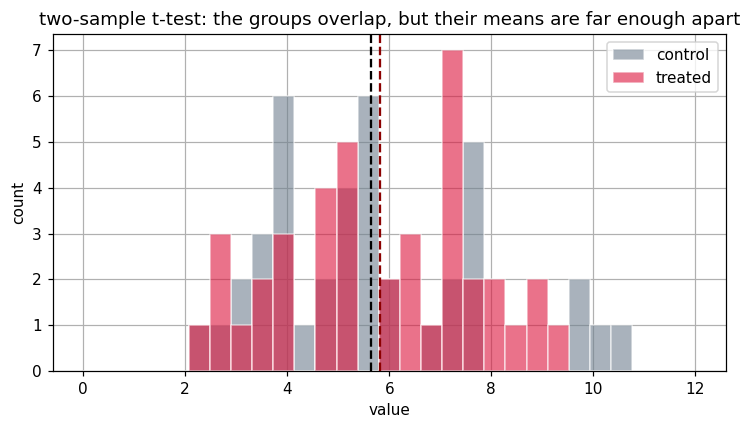

In [18]:
# see what the test sees: two overlapping distributions whose MEANS differ
fig, ax = plt.subplots(figsize=(6.8, 4.0))
bins = np.linspace(0, 12, 30)
ax.hist(control, bins=bins, alpha=0.6, color="slategrey", edgecolor="white", label="control")
ax.hist(treated, bins=bins, alpha=0.6, color="crimson", edgecolor="white", label="treated")
ax.axvline(control.mean(), color="black", ls="--", lw=1.5)
ax.axvline(treated.mean(), color="darkred", ls="--", lw=1.5)
ax.set_xlabel("value"); ax.set_ylabel("count")
ax.set_title("two-sample t-test: the groups overlap, but their means are far enough apart")
ax.legend(); plt.tight_layout(); plt.show()

**check:** the two-sample test returns a tiny p-value and flags significance, because the
means sit clearly apart relative to the within-group spread, even though the histograms overlap
heavily. That overlap is the point: a t-test does not ask "do the groups overlap?", it asks "are
the *means* further apart than chance would comfortably produce?".

❓ **QUESTION.** Shrink the difference by setting `treated`'s `loc` to `5.2` and rerun. The means
still differ on paper, but the p-value climbs above 0.05. Why is it right that a small difference
between noisy groups should *not* be called significant?

### confidence intervals, briefly

A p-value gives a verdict; a **confidence interval** gives a range. A 95% confidence interval for a
mean is a band, built from the sample mean plus or minus roughly two standard errors, constructed
so that across many repeated experiments about 95% of such bands would contain the true mean. It
answers "where, plausibly, does the real mean lie?" rather than just "is it different from a
value?". The two views agree: if a 95% interval for a difference excludes zero, the corresponding
test rejects the null at the 0.05 level.

In [19]:
# a 95% confidence interval for the treated group's mean, from the t distribution
m   = treated.mean()
sem = stats.sem(treated)                       # standard error of the mean, sigma_hat / sqrt(n)
ci_low, ci_high = stats.t.interval(0.95, df=treated.size - 1, loc=m, scale=sem)
print(f"treated mean = {m:.2f}")
print(f"95% confidence interval for the mean = ({ci_low:.2f}, {ci_high:.2f})")
print("we are 95% confident the true mean lies in that band.")

treated mean = 5.81
95% confidence interval for the mean = (5.19, 6.43)
we are 95% confident the true mean lies in that band.


### one bridge to keep for later: rank-based tests

The t-test assumes the data is roughly bell-shaped and compares *means*. Real measurements,
including lipid intensities, are often skewed or carry outliers that drag a mean around. When that
assumption is shaky, you reach for a **nonparametric** test instead: one that throws away the raw
values, **ranks** all observations from smallest to largest, and asks whether one group
systematically holds the higher ranks. Because it works on order rather than magnitude, it needs no
bell-curve assumption and shrugs off outliers.

The course's differential analysis uses exactly such a rank-based test (the Wilcoxon rank-sum test,
also called Mann-Whitney U) to compare lipids between conditions. You do not need it in depth yet:
just hold the idea that "compare the ranks instead of the means" is the robust cousin of the t-test,
and you will meet the full machinery, with multiple-testing correction, in the course notebook where
the real comparison is made.

For unhurried refreshers on tests and p-values, StatQuest's "p-values, clearly explained" and the
*Statistics Fundamentals* playlist linked at the top of part 2 are the friendliest starting points,
and Seeing Theory's "Frequentist Inference" chapter lets you *play* with these ideas.

---
## what you can now lean on

You have refreshed the whole toolbox the course will reach for:

**linear algebra**
- a vector is a list and an arrow; addition is tip to tail, scaling stretches.
- the dot product gives length and angle, and a zero dot product means perpendicular.
- a matrix is both a table of data (rows are samples, columns are features) and a transformation
  of space; matrix multiplication is many dot products at once.
- independence, basis, dimension, and rank measure how much room a set of vectors truly fills.
- projection splits a vector into "along a direction" plus a perpendicular residual.
- eigenvectors are the directions a matrix only stretches, and on a covariance matrix they point
  along the data's main spread, the foundation the course's dimensionality reduction stands on.

**probability and statistics**
- a random variable has a distribution; the normal bell curve appears whenever many small effects
  add up (the central limit theorem), summarised by mean, variance, and standard deviation.
- a sample estimates a population; the sample mean wobbles with standard error `sigma/sqrt(n)`.
- Pearson correlation scores linear co-movement; linear regression fits the best line by least
  squares and reports R squared; curve_fit extends the same fitting idea to nonlinear models.
- hypothesis testing weighs a null against the data through a test statistic and a p-value; the
  Student's t-test compares means, with degrees of freedom setting the bar; confidence intervals
  give the plausible range, and rank-based tests are the robust cousin you will use later.

None of these is the end of the road; each is a floor. When a course notebook fits an embedding,
clusters pixels, corrects a batch effect, or tests a lipid, it is standing on exactly these ideas.
Run this notebook again whenever one of them feels wobbly. See you in Bordeaux.